In [1]:
# conda activate meteor (becasue python 9 is installed here)
# rm -r venv
# make first-venv
# make clean
# make virtual-environment
# source venv/bin/activate
# then select the kernel 'venv' in jupyter notebook

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
#warnings.filterwarnings('ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
#warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from tqdm import tqdm

In [2]:
cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

### Getting some data that can be used by the forcer engine and ciceroscm

SSP245 for aerorol residual from abrupt-4xCO2

In [3]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt"))
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

standard SSP scenarios

In [4]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]

In [5]:
%%capture
#For predictions: read in SSP concentrations and emissions
#scenarios = ["ssp126","ssp245","ssp370","ssp585"]

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_fwd=[]
em_data_fwd=[]
for i,s in enumerate(scenarios):
    conc_data_fwd.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_fwd.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

SSP534-over

In [6]:
%%capture
#For predictions: read in SSP concentrations and emissions

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_ssp534=[]
em_data_ssp534=[]
for i,s in enumerate(['ssp534-over']):
    conc_data_ssp534.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_ssp534.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

### Getting data for standard scenarios

Getting CMIP6 data from the zarrstore for tas

In [7]:
flds = ["tas","pr"]

In [8]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [9]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [10]:
# remove problematic models when creating the pattern
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))  # drop because bad data
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))  # drop because of data issue
if 'TaiESM1' in models: models.pop(models.index('TaiESM1'))  # drop because of data issue
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))  # drop because of data issue in pr
if 'GISS-E2-1-G' in models: models.pop(models.index('GISS-E2-1-G'))  # drop temperature fit doesn't work
if 'MIROC6' in models: models.pop(models.index('MIROC6'))
if 'MPI-ESM1-2-LR' in models: models.pop(models.index('MPI-ESM1-2-LR'))
if 'FGOALS-g3' in models: models.pop(models.index('FGOALS-g3'))    # data offset between piC and hist
if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))
if 'CESM2-WACCM' in models: models.pop(models.index('CESM2-WACCM'))  # no data after 2050 for tas in SSP370

In [11]:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),#.isel(year=slice(-200, None)),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")).isel(year=slice(0, 150)),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")).isel(year=slice(0,251)),
        "ssp126": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp126_training_data.nc")).isel(year=slice(0,251)),
        "ssp245": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp245_training_data.nc")).isel(year=slice(0,251)),
        "ssp370": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp370_training_data.nc")).isel(year=slice(0,251)),
        "ssp585": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp585_training_data.nc")).isel(year=slice(0,251)),
    }

### Getting data for SSP534-over

In [12]:
data_getter_ssp534 = Cmip6MeteorDataGetter(exps=["piControl", "historical", "ssp534-over", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP'])

models_ssp534 = data_getter_ssp534.models
len(models_ssp534)

/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/src/meteor/cmip6_meteor_data_getter.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ScenarioMIP' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_all[i][j].loc[n] = tt.values[0]
/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/src/meteor/cmip6_meteor_data_getter.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCAR' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_all[i][j].loc[n] = tt.values[0]
/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/src/meteor/cmip6_meteor_data_getter.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CESM2-WAC

12

In [13]:
if 'UKESM1-0-LL' in models_ssp534: models_ssp534.pop(models_ssp534.index('UKESM1-0-LL'))  # ominous data
if 'EC-Earth3' in models_ssp534: models_ssp534.pop(models_ssp534.index('EC-Earth3'))   # data issue (with pr?)
if 'IPSL-CM6A-LR' in models_ssp534: models_ssp534.pop(models_ssp534.index('IPSL-CM6A-LR'))   # nan data issue
if 'FGOALS-g3' in models_ssp534: models_ssp534.pop(models_ssp534.index('FGOALS-g3'))  # data offset between piC and hist
if 'MIROC6' in models_ssp534: models_ssp534.pop(models_ssp534.index('MIROC6'))
if 'GISS-E2-1-G' in models_ssp534: models_ssp534.pop(models_ssp534.index('GISS-E2-1-G'))

In [14]:
# load locally saved training data
training_data_dict_ssp534={}
for nm,mname in enumerate(models_ssp534):
    #print(nm,mname)

    training_data_dict_ssp534[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")), #.isel(year=slice(-200,None)),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")).isel(year=slice(0, 150)),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")).isel(year=slice(0,251)),
        "ssp534-over": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp534-over_training_data.nc")).isel(year=slice(0,251)),
    }

# Create GHG modes and patterns for all selected models

In [15]:
%%capture

CMIP_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 3, "pr": 3},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
            anom_timescales={"tas": 3, "pr": 3}
        )


In [16]:
%%capture
# also capture the spatial response of the last 20 years (2080--2100)

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitude and longitude
target_lats = target_ds.lat
target_lons = target_ds.lon

# Loop over variables and scenarios
patterns_aer_ssp_common_grid = np.zeros([len(scenarios), len(flds), len(models), len(target_lats), len(target_lons)])
patterns_aer_ssp_common_grid_ts = np.zeros([len(scenarios), len(flds), len(models), 351, len(target_lats), len(target_lons)])

for nv, var in enumerate(flds):
    for nsc, sc in enumerate(scenarios):

        for nm, mname in enumerate(models):
            # Get native data as an xarray DataArray
            native_ds = CMIP_pattern_dict[mname].predict_from_combined_experiment(
                em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True
            )[var].isel(time=slice(-20, None)).mean(dim='time')

            # Interpolate to the target grid
            regridded_data = native_ds.interp(lat=target_lats, lon=target_lons, method="linear")

            # Store in final array
            patterns_aer_ssp_common_grid[nsc, nv, nm, :, :] = np.nansum(regridded_data,0)

        ### temporally resolved
        for nm, mname in enumerate(models):
            native_ds = CMIP_pattern_dict[mname].predict_from_combined_experiment(
                em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True
            )

            native_data = np.sum(native_ds[var].values, axis=0)

            # Convert to xarray DataArray
            native_da = xr.DataArray(native_data, dims=["time", "lat", "lon"],
                                 coords={"time": np.arange(0,351),
                                         "lat": native_ds[var].lat,
                                         "lon": native_ds[var].lon})

            # Interpolate to the target grid
            regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

            # Store in final array
            patterns_aer_ssp_common_grid_ts[nsc, nv, nm, :, :, :] = regridded_data

##del(model_data_list)
del(CMIP_pattern_dict)

# Application to new scenarios

### SSP534-over

In [17]:
%%capture

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitudes and longitudes
target_lats = target_ds.lat
target_lons = target_ds.lon

# Preallocate final mean array
patterns_ssp534_common_grid = np.zeros([1, len(flds), len(models), len(target_lats), len(target_lons)])
patterns_ssp534_common_grid_ts = np.zeros([1, len(flds), len(models_ssp534), 351, len(target_lats), len(target_lons)])


# Store predictions
patterns_ssp534 = {}

for nm, mname in enumerate(models_ssp534):
    patterns_ssp534[mname] = {}

    # Create pattern scaling object
    CMIP_pattern_ssp534 = MeteorPatternScaling(
        mname,
        {"tas": 3, "pr": 3},
        lambda key: training_data_dict_ssp534[mname][key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"],
        anom_timescales={"tas": 3, "pr": 3}
    )

    # Process SSP534-over scenario
    sc = "ssp534-over"
    patterns_ssp534[mname][sc] = CMIP_pattern_ssp534.predict_from_combined_experiment(
        em_data_ssp534[0], conc_data_ssp534[0], ["pr", "tas"], return_patterns_per_mode=True
    )

# Interpolation and Model Mean Calculation
for nv, var in enumerate(flds):

    for nm, mname in enumerate(models_ssp534):
        # Extract native data and compute mean over last 20 years
        native_data = np.nanmean(
            np.sum(patterns_ssp534[mname][sc][var].values[:, -20:, :, :], axis=0), axis=0
        )

        # Convert to xarray DataArray
        native_da = xr.DataArray(native_data, dims=["lat", "lon"],
                                 coords={"lat": patterns_ssp534[mname][sc][var].lat,
                                         "lon": patterns_ssp534[mname][sc][var].lon})

        # Interpolate to common grid
        regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

        # Store in final array
        patterns_ssp534_common_grid[0, nv, nm, :, :] = regridded_data.values


        ### temporally resolved
        native_data = np.sum(patterns_ssp534[mname][sc][var].values[:, :, :, :], axis=0)

        # Convert to xarray DataArray
        native_da = xr.DataArray(native_data, dims=["time", "lat", "lon"],
                                 coords={"time": np.arange(0,351),
                                         "lat": patterns_ssp534[mname][sc][var].lat,
                                         "lon": patterns_ssp534[mname][sc][var].lon})

        # Interpolate to common grid
        regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

        # Store in final array
        patterns_ssp534_common_grid_ts[0, nv, nm, :, :, :] = regridded_data.values

#del(model_data_list)
del(CMIP_pattern_ssp534)

# Spatial evaluation

interpolate training data: Standard SSPs

In [18]:
%%capture
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

# Define target grid from the reference model
target_model_grid = 'ACCESS-CM2'
target_ds = training_data_dict[target_model_grid]['base']['tas']

# Target latitudes and longitudes
target_lats = target_ds.lat
target_lons = target_ds.lon

# Preallocate final mean array
td_ssp_common_grid = np.zeros([len(flds), len(scenarios), len(models), len(target_lats), len(target_lons)])

# Loop over variables and scenarios (no model loop needed)
for nv, var in enumerate(flds):
    for nsc, sc in enumerate(scenarios):
        #model_data_list = []

        for nm, mname in enumerate(models):
            # Extract native data and compute anomaly
            native_ds = training_data_dict[mname][sc][var]
            native_data = np.nanmean(native_ds.values[0, -20:, :, :], axis=0) - np.nanmean(native_ds.values[0, :50, :, :], axis=0)

            # Convert to xarray DataArray
            native_da = xr.DataArray(native_data, dims=["lat", "lon"], coords={"lat": native_ds.lat, "lon": native_ds.lon})

            # Interpolate to common grid
            regridded_data = native_da.interp(lat=target_lats, lon=target_lons, method="linear")

            #model_data_list.append(regridded_data)

        # Compute model mean after interpolation
        # native_data_mean = xr.concat(model_data_list, dim="model").mean(dim="model")

            # Store in final array
            td_ssp_common_grid[nv, nsc, nm, :, :] = regridded_data #native_data_mean.values


SSP534-over

In [19]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp534_common_grid = np.zeros([len(flds),1,len(models_ssp534),len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100
            native_lons = training_data_dict_ssp534[mname][sc][var].lon
            native_lats = training_data_dict_ssp534[mname][sc][var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            td_ssp534_common_grid[nv,nsc,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


## Plotting

tas - standard SSPs

In [21]:
var_idx = 0
levels = np.arange(-10,10.1,1)
cmap="RdBu_r"

for nm, mname in enumerate(models):
    print(nm, mname)

    fig = plt.figure(figsize=(15,12))
    gs = GridSpec(4, 3, figure=fig)

    # row 1
    sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[0,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    #cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
    #cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
    sub.set_aspect(1.1)
    sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, td_ssp_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)  
    sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR-CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[0,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    #row 2
    sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[1,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-2.45', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, td_ssp_common_grid[var_idx,1,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1) 
    sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[1,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,1,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    #row 3
    sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[2,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-3.70', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats,td_ssp_common_grid[var_idx,2,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1) 
    sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[2,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,2,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    #row 4
    sub = fig.add_subplot(gs[3, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[3,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
    cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
    fig.text(0.241,0.071,"$\Delta$T [K]",ha="center")
    sub.set_aspect(1.1)
    sub.annotate('j', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[3, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats,td_ssp_common_grid[var_idx,3,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1) 
    sub.annotate('k', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[3, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[3,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,3,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
    cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
    fig.text(0.652,0.071,"$\Delta$T [K]",ha="center")
    sub.set_aspect(1.1)
    sub.annotate('l', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    fig.subplots_adjust(wspace=0.2, hspace=0.15)
    plt.savefig(os.path.join(figdir+"/CMIP_recon_SSPs_spatial", "CMIP_recon_SSPs_spatial_tas_"+mname+".pdf"), bbox_inches='tight')
    plt.close(fig)

0 ACCESS-CM2
1 ACCESS-ESM1-5
2 AWI-CM-1-1-MR
3 BCC-CSM2-MR
4 CAMS-CSM1-0
5 CAS-ESM2-0
6 CESM2
7 CMCC-CM2-SR5
8 CMCC-ESM2
9 CNRM-CM6-1
10 CNRM-CM6-1-HR
11 CNRM-ESM2-1
12 CanESM5
13 EC-Earth3-Veg
14 FGOALS-f3-L
15 GFDL-ESM4
16 GISS-E2-1-H
17 INM-CM4-8
18 INM-CM5-0
19 KACE-1-0-G
20 MCM-UA-1-0
21 MIROC-ES2L
22 MPI-ESM1-2-HR
23 NorESM2-MM
24 UKESM1-0-LL


tas - SSP5-3.4

0 CESM2-WACCM
1 CMCC-ESM2
2 CNRM-ESM2-1
3 CanESM5
4 MIROC-ES2L
5 MRI-ESM2-0


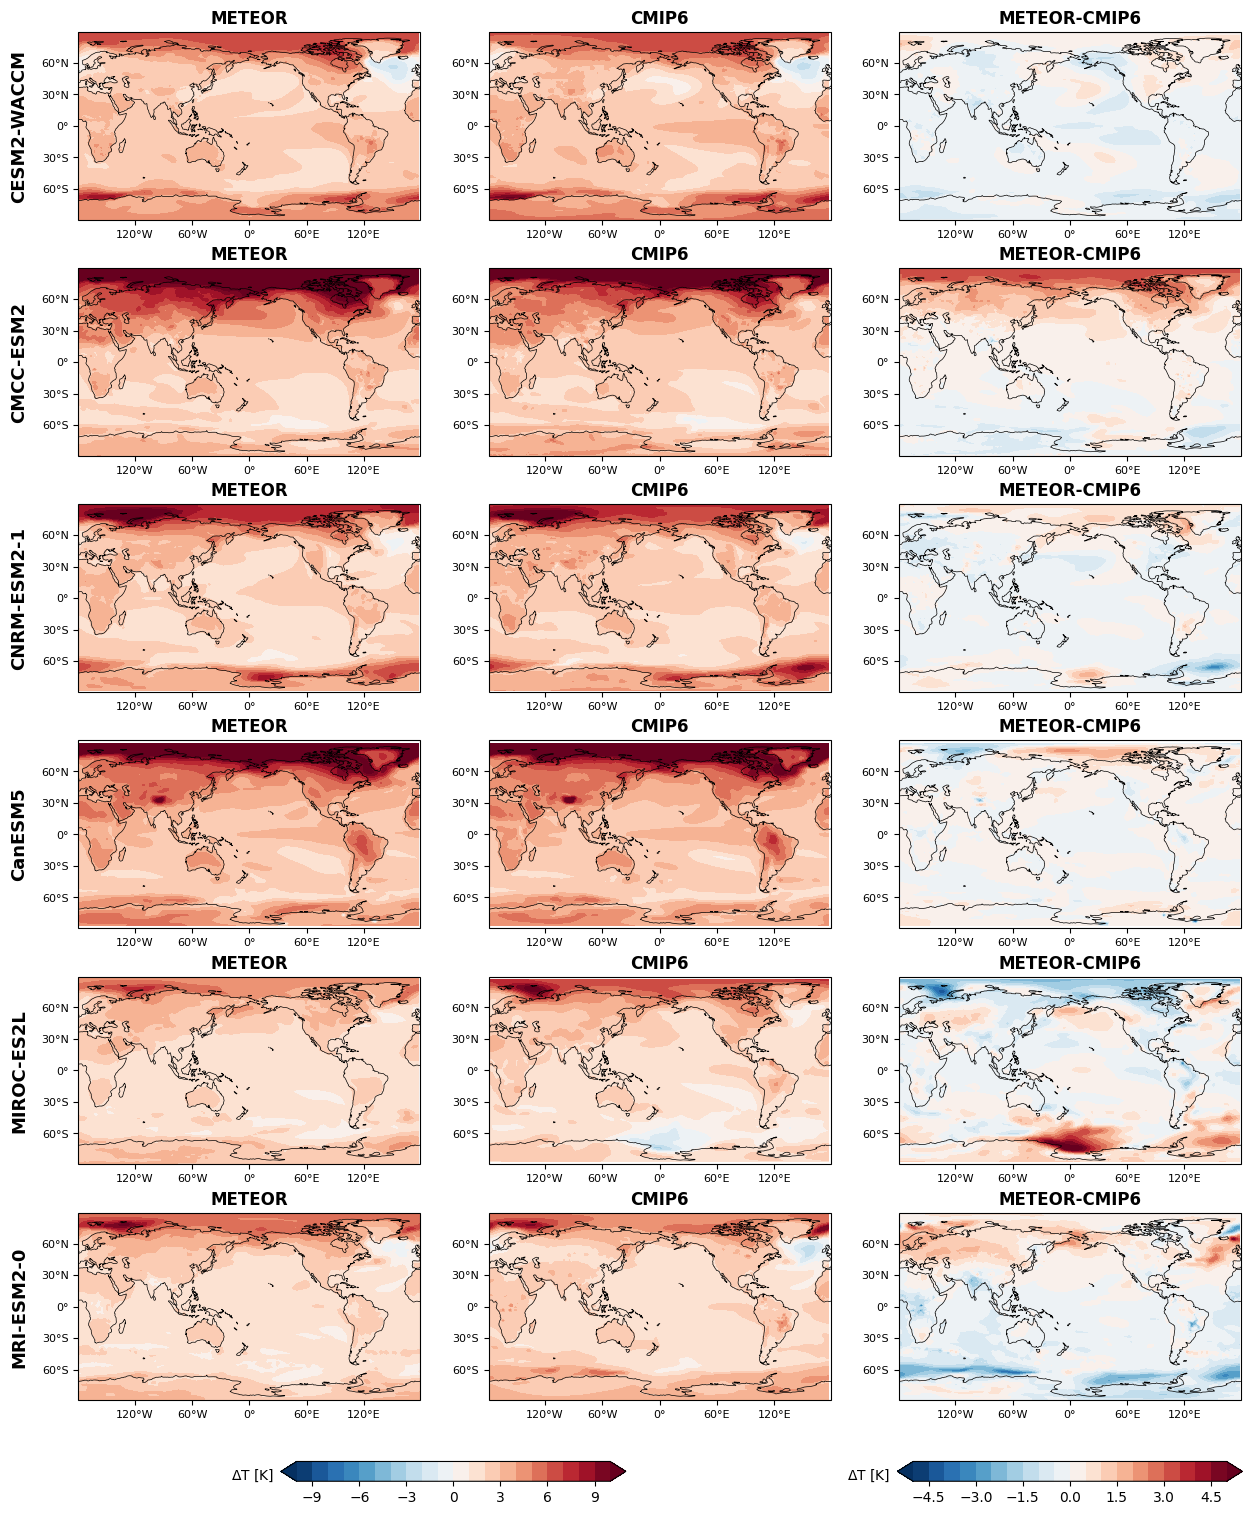

In [22]:
fig = plt.figure(figsize=(15,18))
gs = GridSpec(6, 3, figure=fig)

for nm, mname in enumerate(models_ssp534):
    print(nm, mname)

    sub = fig.add_subplot(gs[nm, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid[0,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    if nm == 0:
        cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
        cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        fig.text(0.241,0.071,"$\Delta$T [K]",ha="center")
    sub.set_aspect(1.1)
    #sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate(mname, xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[nm, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, td_ssp534_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    #sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nm, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR-CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid[0,var_idx,nm,:,:]-td_ssp534_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    if nm == 0:
        cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
        cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        fig.text(0.652,0.071,"$\Delta$T [K]",ha="center")
    sub.set_aspect(1.1)
    #sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    fig.subplots_adjust(wspace=0.2, hspace=0.15)
    plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_spatial_tas.pdf"), bbox_inches='tight')

pr - standard SSPs

In [23]:
var_idx = 1
levels = np.arange(-3e-5,3.1e-5,0.5e-5)
cmap="BrBG"

for nm, mname in enumerate(models):
    print(nm, mname)

    fig = plt.figure(figsize=(15,12))
    gs = GridSpec(4, 3, figure=fig)

    # row 1
    sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[0,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    #cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
    #cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
    sub.set_aspect(1.1)
    sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, td_ssp_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)  
    sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR-CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[0,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    #row 2
    sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[1,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-2.45', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats,td_ssp_common_grid[var_idx,1,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1) 
    sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[1,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,1,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    #row 3
    sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[2,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-3.70', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats,td_ssp_common_grid[var_idx,2,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1) 
    sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[2,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,2,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    #row 4
    sub = fig.add_subplot(gs[3, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[3,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
    cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
    fig.text(0.219,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
    sub.set_aspect(1.1)
    sub.annotate('j', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[3, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats,td_ssp_common_grid[var_idx,3,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1) 
    sub.annotate('k', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[3, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_aer_ssp_common_grid[3,var_idx,nm,:,:]-td_ssp_common_grid[var_idx,3,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
    cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
    fig.text(0.628,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
    sub.set_aspect(1.1)
    sub.annotate('l', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    fig.subplots_adjust(wspace=0.2, hspace=0.15)
    plt.savefig(os.path.join(figdir+"/CMIP_recon_SSPs_spatial", "CMIP_recon_SSPs_spatial_pr_"+mname+".pdf"), bbox_inches='tight')
    plt.close(fig)

0 ACCESS-CM2
1 ACCESS-ESM1-5
2 AWI-CM-1-1-MR
3 BCC-CSM2-MR
4 CAMS-CSM1-0
5 CAS-ESM2-0
6 CESM2
7 CMCC-CM2-SR5
8 CMCC-ESM2
9 CNRM-CM6-1
10 CNRM-CM6-1-HR
11 CNRM-ESM2-1
12 CanESM5
13 EC-Earth3-Veg
14 FGOALS-f3-L
15 GFDL-ESM4
16 GISS-E2-1-H
17 INM-CM4-8
18 INM-CM5-0
19 KACE-1-0-G
20 MCM-UA-1-0
21 MIROC-ES2L
22 MPI-ESM1-2-HR
23 NorESM2-MM
24 UKESM1-0-LL


pr - SSP5-3.4

0 CESM2-WACCM
1 CMCC-ESM2
2 CNRM-ESM2-1
3 CanESM5
4 MIROC-ES2L
5 MRI-ESM2-0


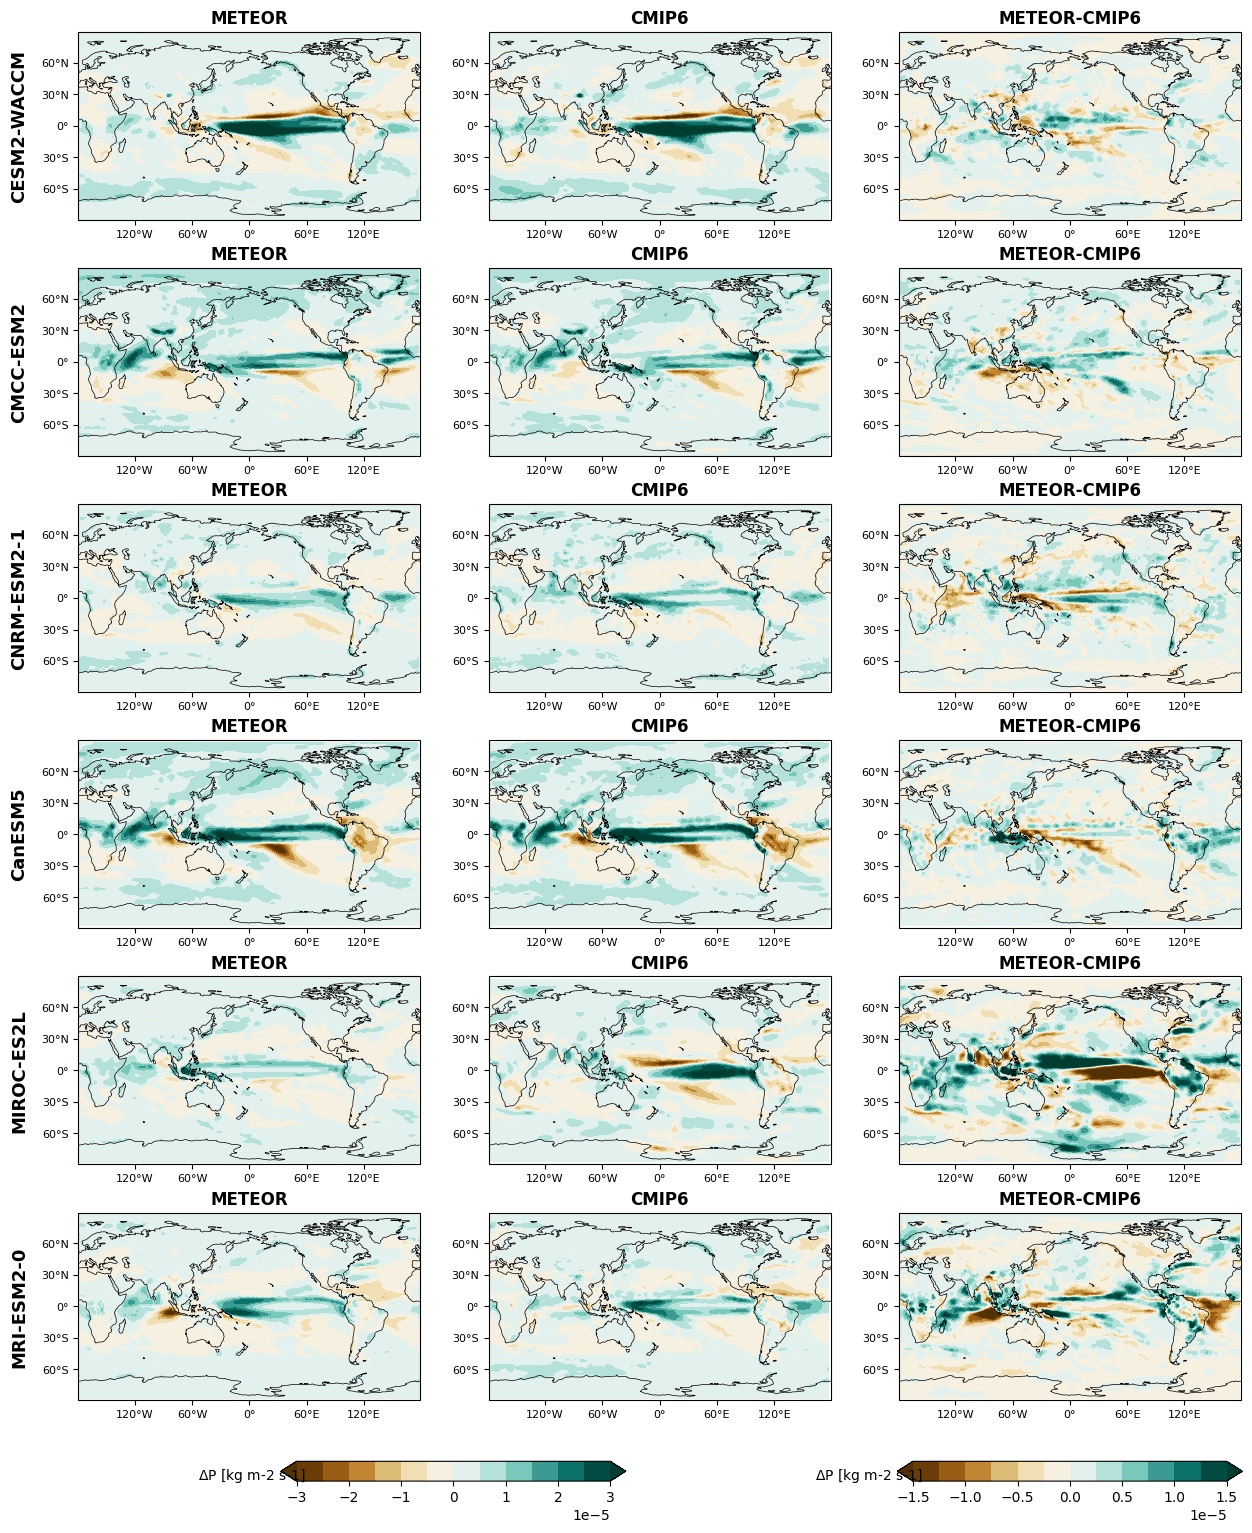

In [24]:
fig = plt.figure(figsize=(15,18))
gs = GridSpec(6, 3, figure=fig)

for nm, mname in enumerate(models_ssp534):
    print(nm, mname)

    sub = fig.add_subplot(gs[nm, 0], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid[0,var_idx,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    if nm == 0:
        cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
        cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        fig.text(0.241,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
    sub.set_aspect(1.1)
    #sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate(mname, xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

    sub = fig.add_subplot(gs[nm, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, td_ssp534_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.1)
    #sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nm, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR-CMIP6', weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, patterns_ssp534_common_grid[0,var_idx,nm,:,:]-td_ssp534_common_grid[var_idx,0,nm,:,:], cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
    if nm == 0:
        cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
        cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        fig.text(0.652,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
    sub.set_aspect(1.1)
    #sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    fig.subplots_adjust(wspace=0.2, hspace=0.15)
    plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_spatial_pr.pdf"), bbox_inches='tight')

Per-model pattern correlation

In [20]:
Pcorr = np.zeros([2,4,len(models)]) * np.nan
Prmse = np.zeros([2,4,len(models)]) * np.nan

for nv,var in enumerate(flds):
    for nsc,sc in enumerate(scenarios):
        for nm,mname in enumerate(models):
            array1 = patterns_aer_ssp_common_grid[nsc,nv,nm,:,:].ravel()
            array2 = td_ssp_common_grid[nv,nsc,nm,:,:].ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc,nm] = correlation
            Prmse[nv,nsc,nm] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE

In [21]:
# Create MultiIndex
index = pd.MultiIndex.from_product(
    [flds, scenarios, models],
    names=["Variable", "Scenario", "Model"]
)

# Create DataFrame
df = pd.DataFrame({"RMSE": Prmse.flatten(), "Pcorr": Pcorr.flatten()}, index=index).reset_index()

# Show the first few rows
df_tas = df[0:100]
df_pr = df[100:200]
print(df_tas)


   Variable Scenario          Model      RMSE     Pcorr
0       tas   ssp126     ACCESS-CM2  0.481650  0.986349
1       tas   ssp126  ACCESS-ESM1-5  0.546740  0.959164
2       tas   ssp126  AWI-CM-1-1-MR  0.433557  0.974182
3       tas   ssp126    BCC-CSM2-MR  0.657037  0.826822
4       tas   ssp126    CAMS-CSM1-0  0.424803  0.853403
..      ...      ...            ...       ...       ...
95      tas   ssp585     MCM-UA-1-0  0.661020  0.973407
96      tas   ssp585     MIROC-ES2L  0.585281  0.976479
97      tas   ssp585  MPI-ESM1-2-HR  0.526779  0.979746
98      tas   ssp585     NorESM2-MM  0.551416  0.993332
99      tas   ssp585    UKESM1-0-LL  0.678329  0.991874

[100 rows x 5 columns]


In [22]:
print("RMSE ranking:")
for nv,var in enumerate(flds):
    for nsc,sc in enumerate(scenarios):
        print(df[(df["Variable"] == var) & (df["Scenario"] == sc)].sort_values("RMSE", ascending=True).values[0])

print("Pcorr ranking:")
for nv,var in enumerate(flds):
    for nsc,sc in enumerate(scenarios):
        print(df[(df["Variable"] == var) & (df["Scenario"] == sc)].sort_values("Pcorr", ascending=True).values[0])


RMSE ranking:
['tas' 'ssp126' 'NorESM2-MM' 0.24739282080202288 0.9781189950608571]
['tas' 'ssp245' 'NorESM2-MM' 0.17150196932455883 0.995784425387847]
['tas' 'ssp370' 'AWI-CM-1-1-MR' 0.31805227062252495 0.9911994752746796]
['tas' 'ssp585' 'CAMS-CSM1-0' 0.30764613353466697 0.9850530626279324]
['pr' 'ssp126' 'NorESM2-MM' 1.6651067763826482e-06 0.8404204845099702]
['pr' 'ssp245' 'CAS-ESM2-0' 8.988435784382369e-07 0.9834571067705552]
['pr' 'ssp370' 'CNRM-CM6-1-HR' 1.7668456180361582e-06 0.9393365889629472]
['pr' 'ssp585' 'MPI-ESM1-2-HR' 2.066343412942816e-06 0.9119684205366606]
Pcorr ranking:
['tas' 'ssp126' 'GFDL-ESM4' 0.6014083230050917 0.8137307366758961]
['tas' 'ssp245' 'BCC-CSM2-MR' 0.5871581560161268 0.9527540458749966]
['tas' 'ssp370' 'BCC-CSM2-MR' 1.1077162694202254 0.9583267138868272]
['tas' 'ssp585' 'GFDL-ESM4' 0.7814875662649933 0.9582071280854156]
['pr' 'ssp126' 'CAMS-CSM1-0' 1.9985906557274424e-06 0.5283895937458757]
['pr' 'ssp245' 'MCM-UA-1-0' 1.7333408901306098e-06 0.8463136

In [23]:
df_tas.groupby(["Variable", "Model"])["RMSE"].sum().reset_index().rename(columns={"RMSE": "RMSE_sum"}).sort_values("RMSE_sum")

,Variable,Model,RMSE_sum
23,tas,NorESM2-MM,1.353642
14,tas,FGOALS-f3-L,1.441024
2,tas,AWI-CM-1-1-MR,1.474841
4,tas,CAMS-CSM1-0,1.493250
1,tas,ACCESS-ESM1-5,1.543672
5,tas,CAS-ESM2-0,1.631196
21,tas,MIROC-ES2L,1.776818
17,tas,INM-CM4-8,1.776818
18,tas,INM-CM5-0,1.821286
22,tas,MPI-ESM1-2-HR,1.821286


In [24]:
df_pr.groupby(["Variable", "Model"])["RMSE"].sum().reset_index().rename(columns={"RMSE": "RMSE_sum"}).sort_values("RMSE_sum")

,Variable,Model,RMSE_sum
5,pr,CAS-ESM2-0,0.000007
10,pr,CNRM-CM6-1-HR,0.000007
23,pr,NorESM2-MM,0.000007
9,pr,CNRM-CM6-1,0.000007
22,pr,MPI-ESM1-2-HR,0.000007
18,pr,INM-CM5-0,0.000007
15,pr,GFDL-ESM4,0.000008
17,pr,INM-CM4-8,0.000008
21,pr,MIROC-ES2L,0.000008
4,pr,CAMS-CSM1-0,0.000008


# Regional evaluation

interpolate temporally resolved training data - standard SSPs

In [ ]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Note: some models have less than 251 values, so need to use the smalles possible common period
td_ssp_common_grid_ts = np.zeros([len(flds),len(scenarios),len(models),249,len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            native_data = training_data_dict[mname][sc][var].values[0,0:249,:,:]
            native_lons = training_data_dict[mname][sc][var].lon
            native_lats = training_data_dict[mname][sc][var].lat
            #native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            native_da = xr.DataArray(
                native_data,
                dims=["time", "lat", "lon"],
                coords={"time": np.arange(0,249), "lat": native_lats, "lon": native_lons}
            )

            regridded_da = native_da.interp(lat=common_lats, lon=common_lons, method="linear")

            # Interpolate
            #td_ssp534_common_grid[nv,nsc,nm,:,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
            #                                np.array(native_data).flatten(), 
            #                                (common_lon_grid, common_lat_grid), method='cubic')
            td_ssp_common_grid_ts[nv, nsc, nm, :, :, :] = regridded_da.values


: 

interpolate temporally resolved training data - SSP534

In [ ]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp534_common_grid_ts = np.zeros([len(flds),1,len(models_ssp534),251,len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            native_data = training_data_dict_ssp534[mname][sc][var].values[0,:,:,:]
            native_lons = training_data_dict_ssp534[mname][sc][var].lon
            native_lats = training_data_dict_ssp534[mname][sc][var].lat
            #native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            native_da = xr.DataArray(
                native_data,
                dims=["time", "lat", "lon"],
                coords={"time": np.arange(0,251), "lat": native_lats, "lon": native_lons}
            )

            regridded_da = native_da.interp(lat=common_lats, lon=common_lons, method="linear")

            # Interpolate
            #td_ssp534_common_grid[nv,nsc,nm,:,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
            #                                np.array(native_data).flatten(), 
            #                                (common_lon_grid, common_lat_grid), method='cubic')
            td_ssp534_common_grid_ts[nv, nsc, nm, :, :, :] = regridded_da.values


Define regions

In [36]:
EUR_bnds = {"lon_min": 0, "lon_max": 45, "lat_min": 37, "lat_max": 75}    # EU
HAR_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": 70, "lat_max": 90}    # High Arctic
HAN_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -90, "lat_max": -55}    # High Antarctic
EQU_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -20, "lat_max": 20} 
SAM_bnds = {"lon_min": 275, "lon_max": 330, "lat_min": -60, "lat_max": 15}  # SAm
NAM_bnds = {"lon_min": 200, "lon_max": 310, "lat_min": 10, "lat_max": 70}  # NAm
SEA_bnds = {"lon_min": 95, "lon_max": 165, "lat_min": -45, "lat_max": 5}  # SEA
EAS_bnds = {"lon_min": 65, "lon_max": 150, "lat_min": 5, "lat_max": 60}   # EAs
AFR_bnds = {"lon_min": 0, "lon_max": 60, "lat_min": -40, "lat_max": 37}   # AF

lon_orig_idx_EU = np.where((common_lons >= EUR_bnds["lon_min"]) & (common_lons <= EUR_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= EUR_bnds["lat_min"]) & (common_lats <= EUR_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= HAR_bnds["lon_min"]) & (common_lons <= HAR_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= HAR_bnds["lat_min"]) & (common_lats <= HAR_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= HAN_bnds["lon_min"]) & (common_lons <= HAN_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= HAN_bnds["lat_min"]) & (common_lats <= HAN_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= EQU_bnds["lon_min"]) & (common_lons <= EQU_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= EQU_bnds["lat_min"]) & (common_lats <= EQU_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= SAM_bnds["lon_min"]) & (common_lons <= SAM_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= SAM_bnds["lat_min"]) & (common_lats <= SAM_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= NAM_bnds["lon_min"]) & (common_lons <= NAM_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= NAM_bnds["lat_min"]) & (common_lats <= NAM_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= SEA_bnds["lon_min"]) & (common_lons <= SEA_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= SEA_bnds["lat_min"]) & (common_lats <= SEA_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= EAS_bnds["lon_min"]) & (common_lons <= EAS_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= EAS_bnds["lat_min"]) & (common_lats <= EAS_bnds["lat_max"]))[0]
lon_orig_idx_EU = np.where((common_lons >= AFR_bnds["lon_min"]) & (common_lons <= AFR_bnds["lon_max"]))[0]
lat_orig_idx_EU = np.where((common_lats >= AFR_bnds["lat_min"]) & (common_lats <= AFR_bnds["lat_max"]))[0]

In [ ]:
EUR_bnds = {"lon_min": 0, "lon_max": 45, "lat_min": 37, "lat_max": 75}    # EU
HAR_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": 70, "lat_max": 90}    # High Arctic
HAN_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -90, "lat_max": -55}    # High Antarctic
EQU_bnds = {"lon_min": 0, "lon_max": 360, "lat_min": -20, "lat_max": 20} 
SAM_bnds = {"lon_min": 275, "lon_max": 330, "lat_min": -60, "lat_max": 15}  # SAm
NAM_bnds = {"lon_min": 200, "lon_max": 310, "lat_min": 10, "lat_max": 70}  # NAm
SEA_bnds = {"lon_min": 95, "lon_max": 165, "lat_min": -45, "lat_max": 5}  # SEA
EAS_bnds = {"lon_min": 65, "lon_max": 150, "lat_min": 5, "lat_max": 60}   # EAs
AFR_bnds = {"lon_min": 0, "lon_max": 60, "lat_min": -40, "lat_max": 37}   # AF

lon_orig_idx = {}
lon_orig_idx["EUR"] = np.where((common_lons >= EUR_bnds["lon_min"]) & (common_lons <= EUR_bnds["lon_max"]))[0]
lon_orig_idx["HAR"] = np.where((common_lons >= HAR_bnds["lon_min"]) & (common_lons <= HAR_bnds["lon_max"]))[0]
lon_orig_idx["HAN"] = np.where((common_lons >= HAN_bnds["lon_min"]) & (common_lons <= HAN_bnds["lon_max"]))[0]
lon_orig_idx["EQU"] = np.where((common_lons >= EQU_bnds["lon_min"]) & (common_lons <= EQU_bnds["lon_max"]))[0]
lon_orig_idx["SAM"] = np.where((common_lons >= SAM_bnds["lon_min"]) & (common_lons <= SAM_bnds["lon_max"]))[0]
lon_orig_idx["NAM"] = np.where((common_lons >= NAM_bnds["lon_min"]) & (common_lons <= NAM_bnds["lon_max"]))[0]
lon_orig_idx["SEA"] = np.where((common_lons >= SEA_bnds["lon_min"]) & (common_lons <= SEA_bnds["lon_max"]))[0]
lon_orig_idx["EAS"] = np.where((common_lons >= EAS_bnds["lon_min"]) & (common_lons <= EAS_bnds["lon_max"]))[0]
lon_orig_idx["AFR"] = np.where((common_lons >= AFR_bnds["lon_min"]) & (common_lons <= AFR_bnds["lon_max"]))[0]

lat_orig_idx = {}
lat_orig_idx["EUR"] = np.where((common_lats >= EUR_bnds["lat_min"]) & (common_lats <= EUR_bnds["lat_max"]))[0]
lat_orig_idx["HAR"] = np.where((common_lats >= HAR_bnds["lat_min"]) & (common_lats <= HAR_bnds["lat_max"]))[0]
lat_orig_idx["HAN"] = np.where((common_lats >= HAN_bnds["lat_min"]) & (common_lats <= HAN_bnds["lat_max"]))[0]
lat_orig_idx["EQU"] = np.where((common_lats >= EQU_bnds["lat_min"]) & (common_lats <= EQU_bnds["lat_max"]))[0]
lat_orig_idx["SAM"] = np.where((common_lats >= SAM_bnds["lat_min"]) & (common_lats <= SAM_bnds["lat_max"]))[0]
lat_orig_idx["NAM"] = np.where((common_lats >= NAM_bnds["lat_min"]) & (common_lats <= NAM_bnds["lat_max"]))[0]
lat_orig_idx["SEA"] = np.where((common_lats >= SEA_bnds["lat_min"]) & (common_lats <= SEA_bnds["lat_max"]))[0]
lat_orig_idx["EAS"] = np.where((common_lats >= EAS_bnds["lat_min"]) & (common_lats <= EAS_bnds["lat_max"]))[0]
lat_orig_idx["AFR"] = np.where((common_lats >= AFR_bnds["lat_min"]) & (common_lats <= AFR_bnds["lat_max"]))[0]

regions = ["EUR","HAR","HAN","EQU","SAM","NAM","SEA","EAS","AFR"]
reg_text = ["Europe", "High Arctic", "High Antarctic", "Tropics", "South America", "North America", "East Asia", "Australia", "Africa"]

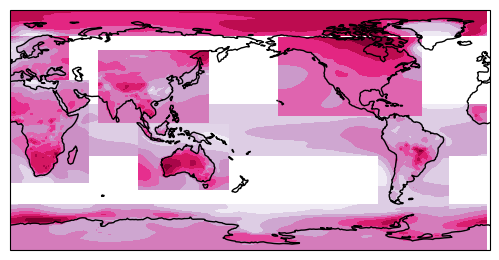

In [38]:
# Plot the regional topography map
fig = plt.figure(figsize=(15, 12.5), layout='tight')

ax = fig.add_subplot(3, 3, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([0,360,-90,90], crs=ccrs.PlateCarree())
ax.coastlines()
for nr,reg in enumerate(regions):
    cont = ax.contourf(common_lons[lon_orig_idx[reg]], common_lats[lat_orig_idx[reg]], patterns_ssp534_common_grid_ts[0,0,0,-1,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1], cmap="PuRd", transform=ccrs.PlateCarree())

Calculate regional means (and realign axes of CMIP and METEOR data, as var and scenario were switched before)

In [42]:
%%capture
td_ssp534_common_grid_ts_reg = np.zeros([len(flds),1,len(models_ssp534),9,251]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            for nr,reg in enumerate(regions):
                region_lats = common_lats[lat_orig_idx[reg]]
                weights = np.cos(np.deg2rad(region_lats))     # Compute weights (cosine of latitude in radians)
                weights = weights / weights.sum()             # Normalize weights

                region_data =  td_ssp534_common_grid_ts[nv, nsc, nm,:,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1] # [time, lat, lon]
                region_mean_lon = np.nanmean(region_data, axis=2)   # First, average over longitude (axis=2)
                region_masked = np.ma.masked_invalid(region_mean_lon)    # filter any nans
                td_ssp534_common_grid_ts_reg[nv, nsc, nm, nr, :] = np.ma.average(region_masked, axis=1, weights=weights).filled(np.nan)     # Then, weighted average over latitude (axis=1)

In [43]:
%%capture
patterns_ssp534_common_grid_ts_reg = np.zeros([len(flds),1,len(models_ssp534),9,351]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            for nr,reg in enumerate(regions):
                region_lats = common_lats[lat_orig_idx[reg]]
                weights = np.cos(np.deg2rad(region_lats))     # Compute weights (cosine of latitude in radians)
                weights = weights / weights.sum()             # Normalize weights

                region_data =  patterns_ssp534_common_grid_ts[nsc, nv, nm,:,np.min(lat_orig_idx[reg]):np.max(lat_orig_idx[reg])+1,np.min(lon_orig_idx[reg]):np.max(lon_orig_idx[reg])+1] # [time, lat, lon]
                region_mean_lon = np.nanmean(region_data, axis=2)   # First, average over longitude (axis=2)
                region_masked = np.ma.masked_invalid(region_mean_lon)    # filter any nans
                patterns_ssp534_common_grid_ts_reg[nv, nsc, nm, nr, :] = np.ma.average(region_masked, axis=1, weights=weights).filled(np.nan)     # Then, weighted average over latitude (axis=1)

time series plots SSP534

In [41]:
for nr,reg in enumerate(regions):

    fig, sub = plt.subplots(2,3,figsize=(15, 6), layout="tight")
    sub=sub.flatten()

    for nm,mname in enumerate(models_ssp534):
        sub[nm].set_title(mname)
        sub[nm].set_ylabel("$\Delta$T [°C]")
        sub[nm].set_xlim(1850,2100)
        sub[nm].plot(np.arange(1850,2101),td_ssp534_common_grid_ts_reg[0,0,nm,nr,:]-np.nanmean(td_ssp534_common_grid_ts_reg[0,0,nm,nr,0:50]), color="tab:red",alpha=0.3)
        sub[nm].plot(np.arange(1850,2101),patterns_ssp534_common_grid_ts_reg[0,0,nm,nr,100:], color="tab:red", linestyle="--")
        if nm == 0:
            sub[nm].set_ylim(-1.8,7.2)
            sub[nm].plot([0,1], color="tab:red", label="$\Delta$T")
            sub[nm].plot([0,1], color="teal", label="$\Delta$P")
            sub[nm].plot([0,1], color="black", label="CMIP6")
            sub[nm].plot([0,1], color="black", linestyle="--", label="METEOR")
            sub[nm].legend(frameon=False, loc="upper left", ncol=2)
        ax2 = sub[nm].twinx()
        ax2.set_ylabel("$\Delta$P [kg m-2 s-1]")
        ax2.plot(np.arange(1850,2101),td_ssp534_common_grid_ts_reg[1,0,nm,nr,:]-np.nanmean(td_ssp534_common_grid_ts_reg[1,0,nm,nr,0:50]), color="teal",alpha=0.3)
        ax2.plot(np.arange(1850,2101),patterns_ssp534_common_grid_ts_reg[1,0,nm,nr,100:], color="teal", linestyle="--")
    
    plt.savefig(os.path.join(figdir+"/CMIP_recon_SSP534_ts_reg", "CMIP_recon_SSP534_ts_reg_"+reg+".pdf"), bbox_inches='tight')
    plt.close(fig)

Scatter plots (METEOR vs. CMIP6) SSP534

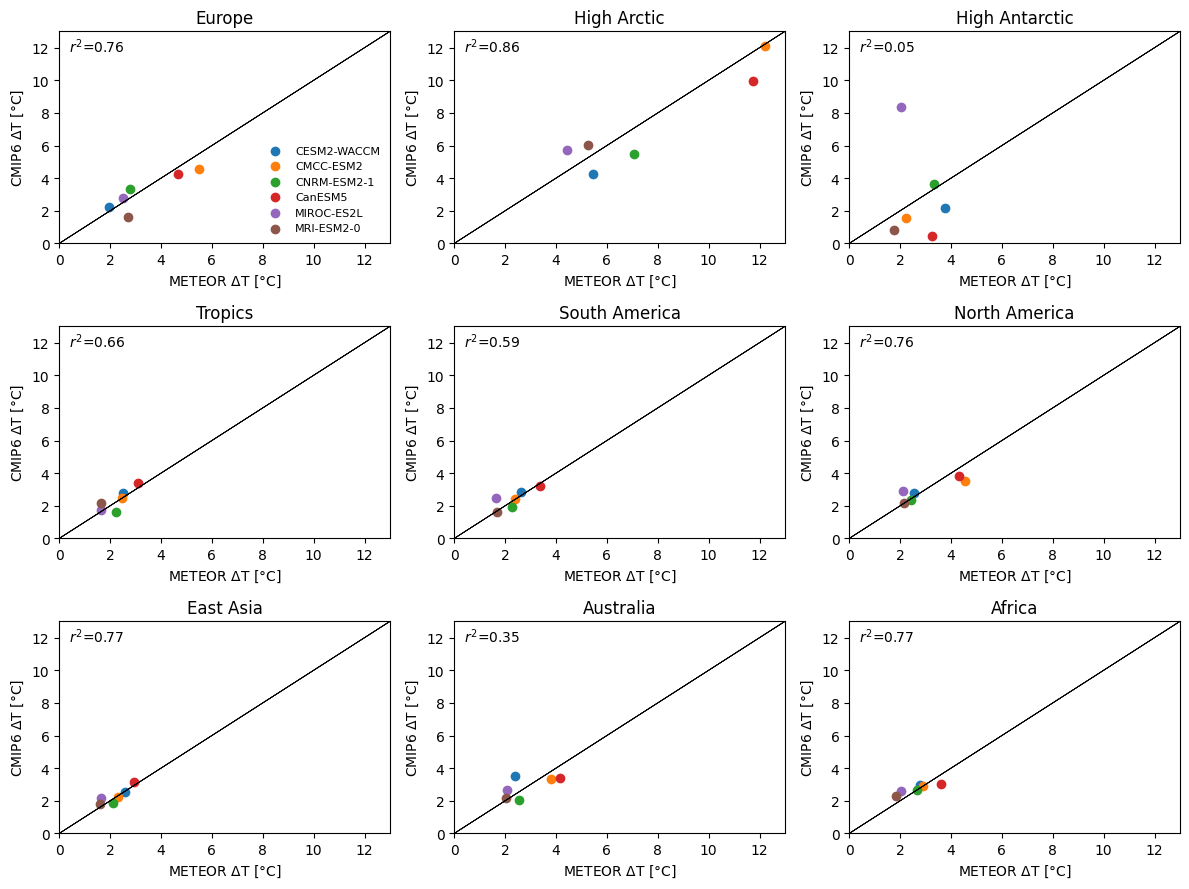

In [ ]:
# varidx = 0

# fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
# axes = axes.flatten()

# for nr, reg in enumerate(regions):
#     ax = axes[nr]
#     ax.set_title(reg_text[nr])
#     meteor = np.nanmean(patterns_ssp534_common_grid_ts_reg[varidx,0,:,nr,-20:],1)
#     cmip = np.nanmean(td_ssp534_common_grid_ts_reg[varidx,0,:,nr,-20:]-np.nanmean(td_ssp534_common_grid_ts_reg[varidx,0,:,nr,0:50]),1)
#     for nm,mname in enumerate(models_ssp534):
#         ax.set_ylabel("CMIP6 $\Delta$T [°C]")
#         ax.set_xlabel("METEOR $\Delta$T [°C]")
#         ax.set_xlim(0,13)
#         ax.set_ylim(0,13)
#         ax.plot([0,13],[0,13], color="black", lw=0.5)
#         ax.scatter(meteor[nm],cmip[nm],label=mname)
#         if nr == 0:
#             ax.legend(frameon=False, loc="lower right", prop={'size': 8})
#         ax.axhline(0, color="gray", lw=0.5, linestyle=":")
#         ax.axvline(0, color="gray", lw=0.5, linestyle=":")
#     r2 = linregress(meteor, cmip).rvalue ** 2
#     ax.annotate(f"$r^2$={r2:.2f}", xy=(0.03, 0.93), xycoords='axes fraction', ha='left', va='center')

# plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_reg_scatter_tas.pdf"), bbox_inches='tight')

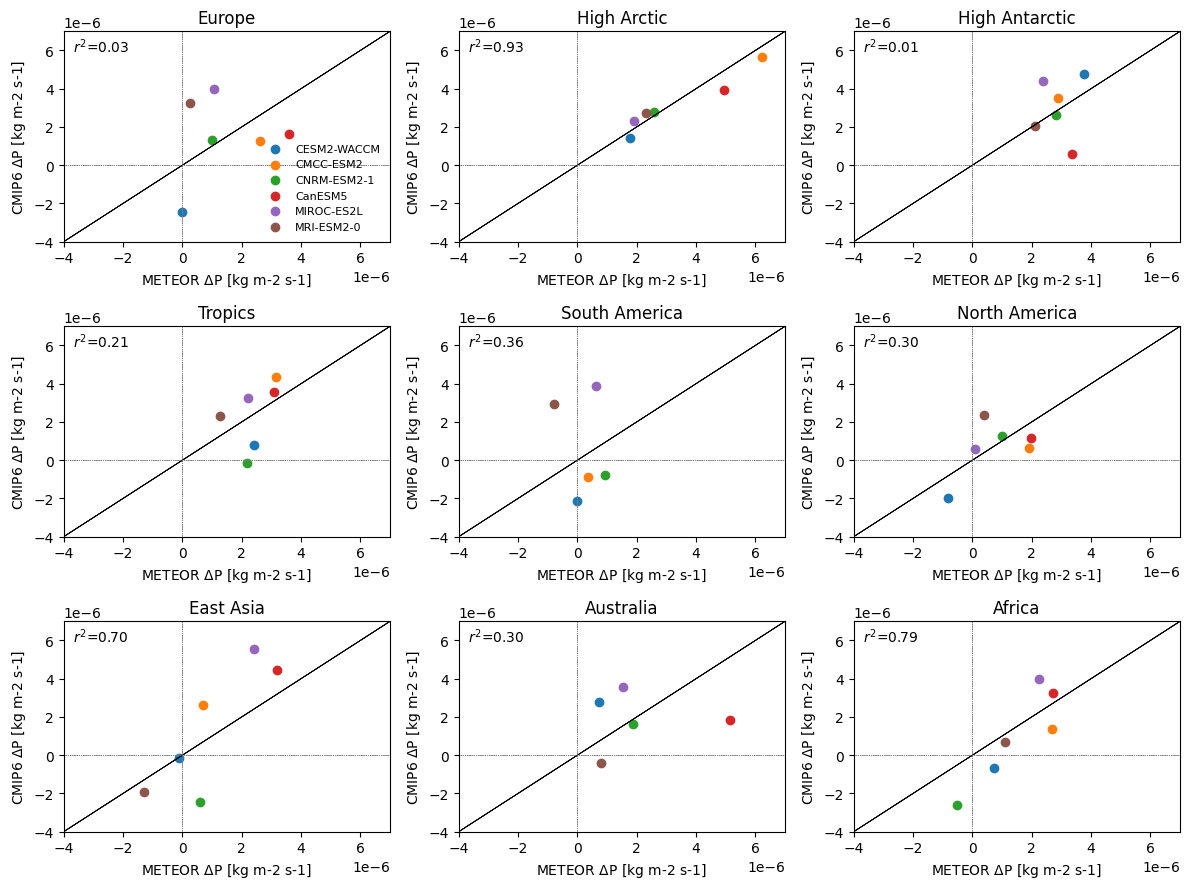

In [ ]:
# varidx = 1

# fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
# axes = axes.flatten()

# for nr, reg in enumerate(regions):
#     ax = axes[nr]
#     ax.set_title(reg_text[nr])
#     meteor = np.nanmean(patterns_ssp534_common_grid_ts_reg[varidx,0,:,nr,-20:],1)
#     cmip = np.nanmean(td_ssp534_common_grid_ts_reg[varidx,0,:,nr,-20:]-np.nanmean(td_ssp534_common_grid_ts_reg[varidx,0,:,nr,0:50]),1)
#     for nm,mname in enumerate(models_ssp534):
#         ax.set_ylabel("CMIP6 $\Delta$P [kg m-2 s-1]")
#         ax.set_xlabel("METEOR $\Delta$P [kg m-2 s-1]")
#         ax.set_xlim(-4e-6,7e-6)
#         ax.set_ylim(-4e-6,7e-6)
#         ax.plot([-4e-6,7e-6],[-4e-6,7e-6], color="black", lw=0.5)
#         ax.scatter(meteor[nm],cmip[nm],label=mname)
#         if nr == 0:
#             ax.legend(frameon=False, loc="lower right", prop={'size': 8})
#         ax.axhline(0, color="gray", lw=0.5, linestyle=":")
#         ax.axvline(0, color="gray", lw=0.5, linestyle=":")
#     r2 = linregress(meteor, cmip).rvalue ** 2
#     ax.annotate(f"$r^2$={r2:.2f}", xy=(0.03, 0.93), xycoords='axes fraction', ha='left', va='center')

# plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_reg_scatter_pr.pdf"), bbox_inches='tight')

Calculate and plot NRMSE over time (Temperature)

In [39]:
# Calculate time-evolving NRMSE and plot for all 6 models per region (9 regions, 3x3 grid)
varidx = 0
n_models = len(models_ssp534)
n_regions = len(regions)
years = np.arange(1850, 2101)
n_years = len(years)

# Only use the first 251 years for CMIP6 (td_ssp534_common_grid_ts_reg), and 251 for METEOR (patterns_ssp534_common_grid_ts_reg, starting at index 100)
cmip6_ts = td_ssp534_common_grid_ts_reg[varidx, 0, :, :, :]  # shape: (models, regions, time=251)
meteor_ts = patterns_ssp534_common_grid_ts_reg[varidx, 0, :, :, 100:351]  # shape: (models, regions, time=251)

# Calculate time-evolving NRMSE for each model and region
nrmse_ts = np.zeros((n_models, n_regions, 251))
for nm in range(n_models):
    for nr in range(n_regions):
        y_true = cmip6_ts[nm, nr, :] - np.nanmean(cmip6_ts[nm, nr, 0:50])
        y_pred = meteor_ts[nm, nr, :]
        denom = np.nanmax(y_true) - np.nanmin(y_true)
        # Time-evolving RMSE up to each time point
        for t in range(251):
            rmse = np.sqrt(np.nanmean((y_true[:t+1] - y_pred[:t+1]) ** 2))
            nrmse_ts[nm, nr, t] = rmse / denom if denom != 0 else np.nan

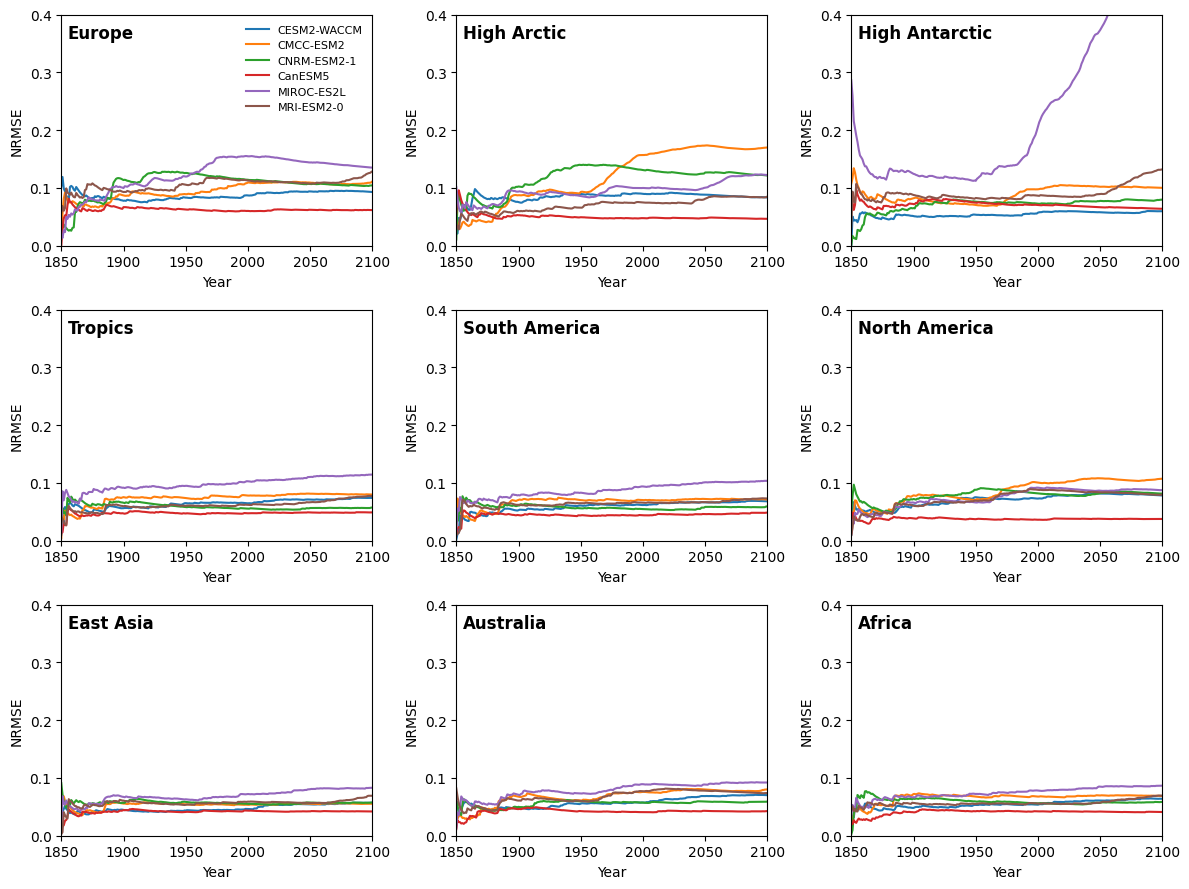

In [40]:
# Plot time-evolving NRMSE for all models per region in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
axes = axes.flatten()

for nr, reg in enumerate(regions):
    ax = axes[nr]
    for nm, mname in enumerate(models_ssp534):
        ax.plot(years, nrmse_ts[nm, nr, :], label=mname)
    ax.set_ylabel("NRMSE")
    ax.set_xlabel("Year")
    ax.set_ylim(0, 0.4)
    ax.set_yticks(np.arange(0,0.41,0.1))
    ax.set_xlim(1850,2100); 
    if nr == 0:
        ax.legend(loc="upper right", fontsize=8, frameon=False)
    ax.annotate(reg_text[nr], xy=(0.02, 0.92), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_reg_NRMSE_ts_tas.pdf"), bbox_inches='tight')

In [41]:
# Calculate time-evolving NRMSE and plot for all 6 models per region (9 regions, 3x3 grid)
varidx = 1
n_models = len(models_ssp534)
n_regions = len(regions)
years = np.arange(1850, 2101)
n_years = len(years)

# Only use the first 251 years for CMIP6 (td_ssp534_common_grid_ts_reg), and 251 for METEOR (patterns_ssp534_common_grid_ts_reg, starting at index 100)
cmip6_ts = td_ssp534_common_grid_ts_reg[varidx, 0, :, :, :]  # shape: (models, regions, time=251)
meteor_ts = patterns_ssp534_common_grid_ts_reg[varidx, 0, :, :, 100:351]  # shape: (models, regions, time=251)

# Calculate time-evolving NRMSE for each model and region
nrmse_ts = np.zeros((n_models, n_regions, 251))
for nm in range(n_models):
    for nr in range(n_regions):
        y_true = cmip6_ts[nm, nr, :] - np.nanmean(cmip6_ts[nm, nr, 0:50])
        y_pred = meteor_ts[nm, nr, :]
        denom = np.nanmax(y_true) - np.nanmin(y_true)
        # Time-evolving RMSE up to each time point
        for t in range(251):
            rmse = np.sqrt(np.nanmean((y_true[:t+1] - y_pred[:t+1]) ** 2))
            nrmse_ts[nm, nr, t] = rmse / denom if denom != 0 else np.nan

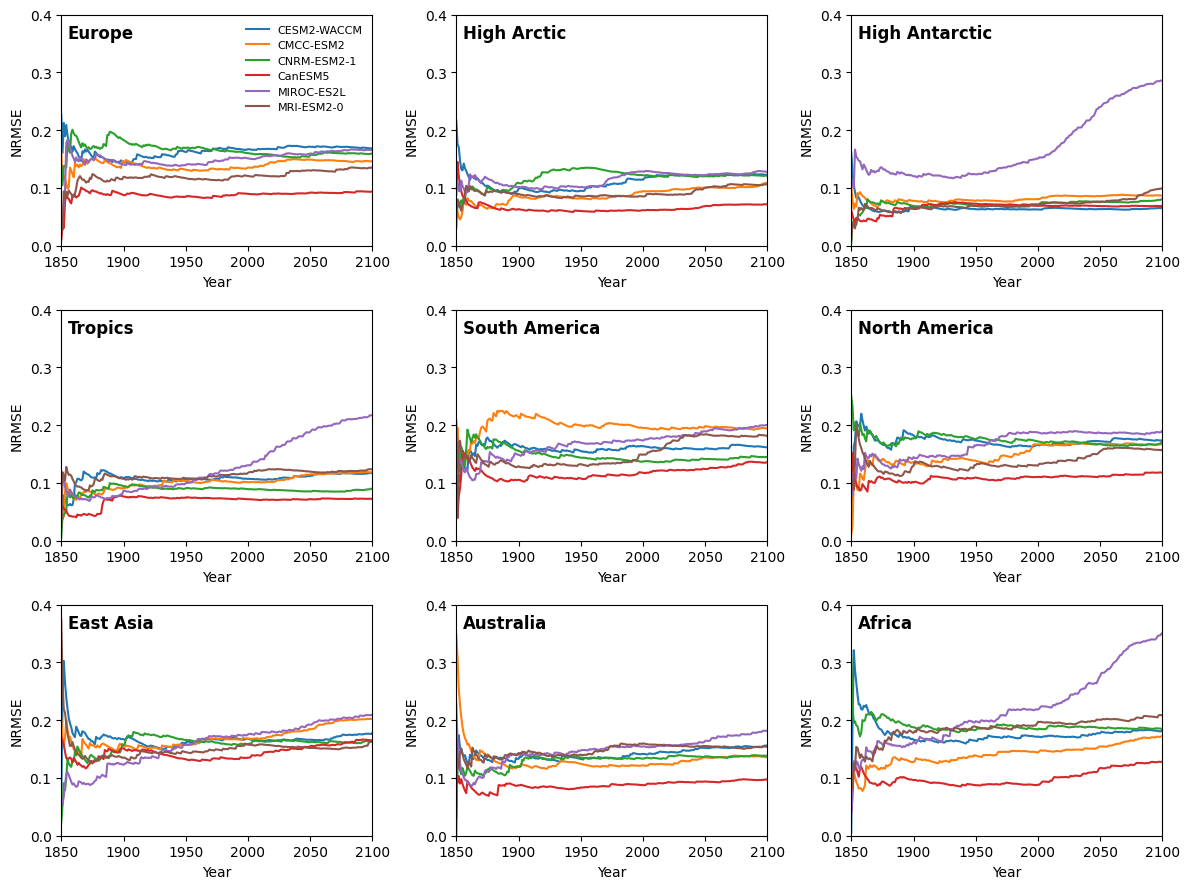

In [42]:
# Plot time-evolving NRMSE for all models per region in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
axes = axes.flatten()

for nr, reg in enumerate(regions):
    ax = axes[nr]
    for nm, mname in enumerate(models_ssp534):
        ax.plot(years, nrmse_ts[nm, nr, :], label=mname)
    ax.set_ylabel("NRMSE")
    ax.set_xlabel("Year")
    ax.set_ylim(0, 0.4)
    ax.set_yticks(np.arange(0,0.41,0.1))
    ax.set_xlim(1850,2100); 
    if nr == 0:
        ax.legend(loc="upper right", fontsize=8, frameon=False)
    ax.annotate(reg_text[nr], xy=(0.02, 0.92), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_reg_NRMSE_ts_pr.pdf"), bbox_inches='tight')

### Correlation between tas and pr

In [43]:
# Calculate global mean using latitude weights

# Latitude weights (cosine of latitude in radians)
lat_weights = np.cos(np.deg2rad(target_lats.values))
lat_weights = lat_weights / lat_weights.sum()  # normalize

# Expand weights to 2D (lat, lon)
weights_2d = np.repeat(lat_weights[:, np.newaxis], len(target_lons), axis=1)
weights_2d = weights_2d / weights_2d.sum()  # normalize over all grid cells

# Calculate global mean for each variable, model, and time
patterns_ssp534_common_grid_ts_gm = np.zeros((1, 2, patterns_ssp534_common_grid_ts.shape[2], patterns_ssp534_common_grid_ts.shape[3]))
td_ssp534_common_grid_ts_gm = np.zeros((1, 2, td_ssp534_common_grid_ts.shape[2], td_ssp534_common_grid_ts.shape[3]))

for v in range(2):
    for m in range(patterns_ssp534_common_grid_ts.shape[2]):

        for t in range(patterns_ssp534_common_grid_ts.shape[3]):
            field = patterns_ssp534_common_grid_ts[0, v, m, t, :, :]  # (lat, lon)
            # Mask NaNs in field and weights
            mask = ~np.isnan(field)
            if np.any(mask):
                w = weights_2d * mask
                w = w / w.sum()  # re-normalize for valid points
                patterns_ssp534_common_grid_ts_gm[0, v, m, t] = np.nansum(field * w)
            else:
                patterns_ssp534_common_grid_ts_gm[0, v, m, t] = np.nan

        for t in range(td_ssp534_common_grid_ts.shape[3]):
            field = td_ssp534_common_grid_ts[v, 0, m, t, :, :]  # (lat, lon)
            # Mask NaNs in field and weights
            mask = ~np.isnan(field)
            if np.any(mask):
                w = weights_2d * mask
                w = w / w.sum()  # re-normalize for valid points
                td_ssp534_common_grid_ts_gm[0, v, m, t] = np.nansum(field * w)
            else:
                td_ssp534_common_grid_ts_gm[0, v, m, t] = np.nan


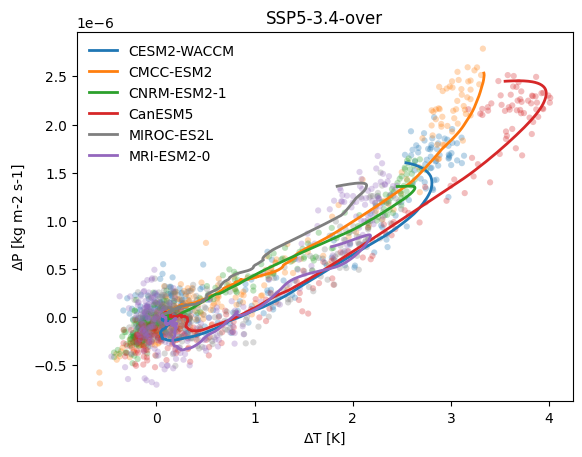

In [44]:
colors = ["tab:blue","tab:orange","tab:green","tab:red","tab:gray","tab:purple"]

for nm, mname in enumerate(models_ssp534):
    plt.title("SSP5-3.4-over")
    plt.ylabel("$\Delta$P [kg m-2 s-1]")
    plt.xlabel("$\Delta$T [K]")
    plt.scatter(td_ssp534_common_grid_ts_gm[0,0,nm,:]-td_ssp534_common_grid_ts_gm[0,0,nm,0],td_ssp534_common_grid_ts_gm[0,1,nm,:]-td_ssp534_common_grid_ts_gm[0,1,nm,0], color=colors[nm], s=20, alpha=0.3, edgecolor="none")
    plt.plot(patterns_ssp534_common_grid_ts_gm[0,0,nm,100:],patterns_ssp534_common_grid_ts_gm[0,1,nm,100:], color=colors[nm], lw=2, label=mname)
    plt.legend(frameon=False, loc="upper left")

plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_pr_tas_corr.pdf"), bbox_inches='tight')

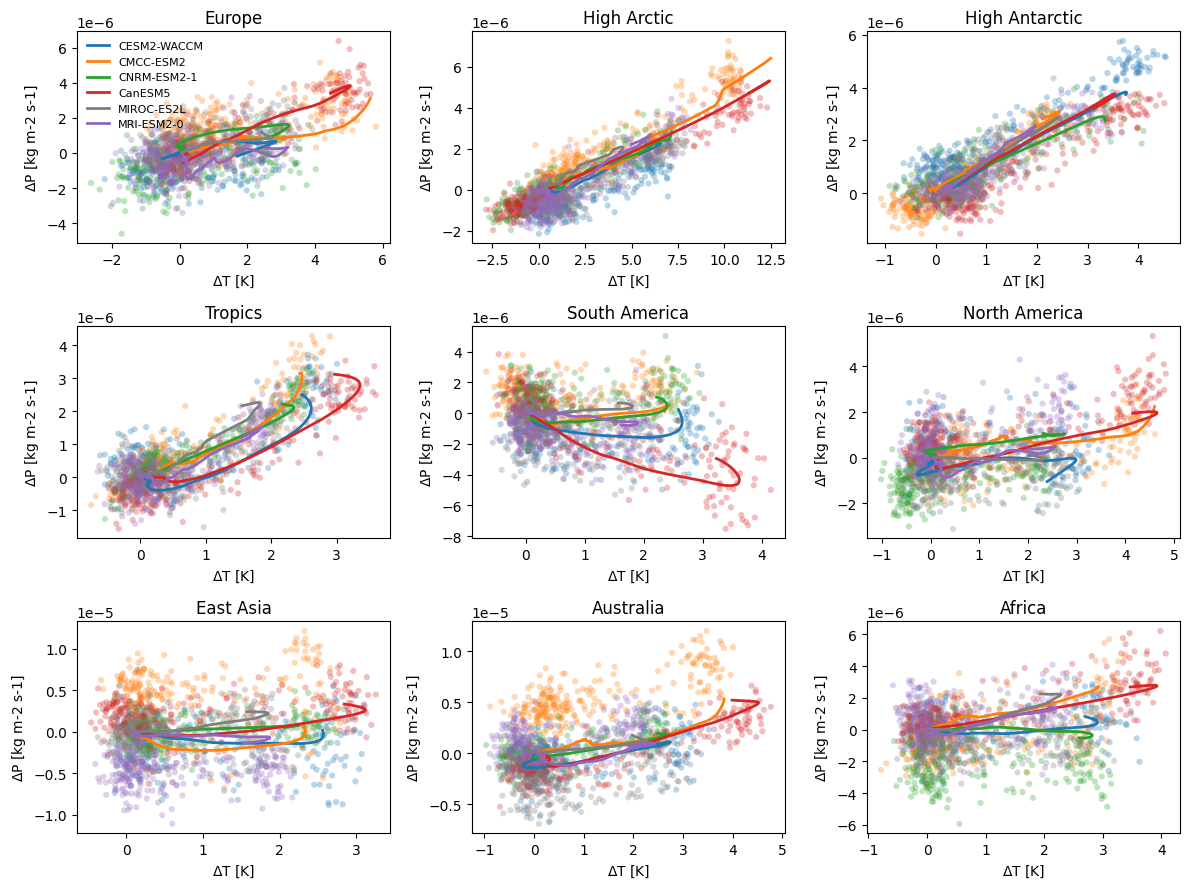

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="tight")
axes = axes.flatten()

for nr, reg in enumerate(regions):
    ax = axes[nr]
    for nm, mname in enumerate(models_ssp534):
        ax.set_title(reg_text[nr])
        ax.set_ylabel("$\Delta$P [kg m-2 s-1]")
        ax.set_xlabel("$\Delta$T [K]")
        ax.scatter(td_ssp534_common_grid_ts_reg[0,0,nm,nr,:]-td_ssp534_common_grid_ts_reg[0,0,nm,nr,0],td_ssp534_common_grid_ts_reg[1,0,nm,nr,:]-td_ssp534_common_grid_ts_reg[1,0,nm,nr,0], color=colors[nm], s=20, alpha=0.3, edgecolor="none")
        ax.plot(patterns_ssp534_common_grid_ts_reg[0,0,nm,nr,100:],patterns_ssp534_common_grid_ts_reg[1,0,nm,nr,100:], color=colors[nm], lw=2, label=mname)
        if nr == 0:
            ax.legend(frameon=False, loc="upper left", prop={'size': 8})

plt.savefig(os.path.join(figdir, "CMIP_recon_SSP534_pr_tas_corr_reg.pdf"), bbox_inches='tight')


### Correlate tas and pr regionally (maps)

In [46]:
from scipy.stats import linregress

In [47]:
n_models = patterns_ssp534_common_grid_ts.shape[2]
n_lat = patterns_ssp534_common_grid_ts.shape[4]
n_lon = patterns_ssp534_common_grid_ts.shape[5]

patterns_ssp534_common_grid_ts_fit = np.full((n_models, n_lat, n_lon), np.nan)
patterns_ssp534_common_grid_ts_fit_intc = np.full((n_models, n_lat, n_lon), np.nan)
patterns_ssp534_common_grid_ts_fit_r2 = np.full((n_models, n_lat, n_lon), np.nan)

td_ssp534_common_grid_ts_fit = np.full((n_models, n_lat, n_lon), np.nan)
td_ssp534_common_grid_ts_fit_intc =np.full((n_models, n_lat, n_lon), np.nan)
td_ssp534_common_grid_ts_fit_r2 = np.full((n_models, n_lat, n_lon), np.nan)

for nm in range(n_models):
    for i in range(n_lat):
        for j in range(n_lon):
            # METEOR
            tas = patterns_ssp534_common_grid_ts[0, 0, nm, 100:, i, j]  # tas time series at this gridpoint
            pr = patterns_ssp534_common_grid_ts[0, 1, nm, 100:, i, j]   # pr time series at this gridpoint
            mask = ~np.isnan(tas) & ~np.isnan(pr)
            if np.sum(mask) > 10:  # Require at least 10 valid points
                res = linregress(tas[mask], pr[mask])
                patterns_ssp534_common_grid_ts_fit[nm, i, j] = res.slope
                patterns_ssp534_common_grid_ts_fit_intc[nm, i, j] = res.intercept
                patterns_ssp534_common_grid_ts_fit_r2[nm, i, j] = res.rvalue
            # CMIP6
            tas = td_ssp534_common_grid_ts[0, 0, nm, :, i, j]  # tas time series at this gridpoint
            pr = td_ssp534_common_grid_ts[1, 0, nm, :, i, j]   # pr time series at this gridpoint
            mask = ~np.isnan(tas) & ~np.isnan(pr)
            if np.sum(mask) > 10:  # Require at least 10 valid points
                res = linregress(tas[mask], pr[mask])
                td_ssp534_common_grid_ts_fit[nm, i, j] = res.slope
                td_ssp534_common_grid_ts_fit_intc[nm, i, j] = res.intercept
                td_ssp534_common_grid_ts_fit_r2[nm, i, j] = res.rvalue
            

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_84291/2319086439.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "CMIP_SSP534_pr_tas_corr_spatial.pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_84291/2319086439.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "CMIP_SSP534_pr_tas_corr_spatial.pdf"), bbox_inches='tight')
/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


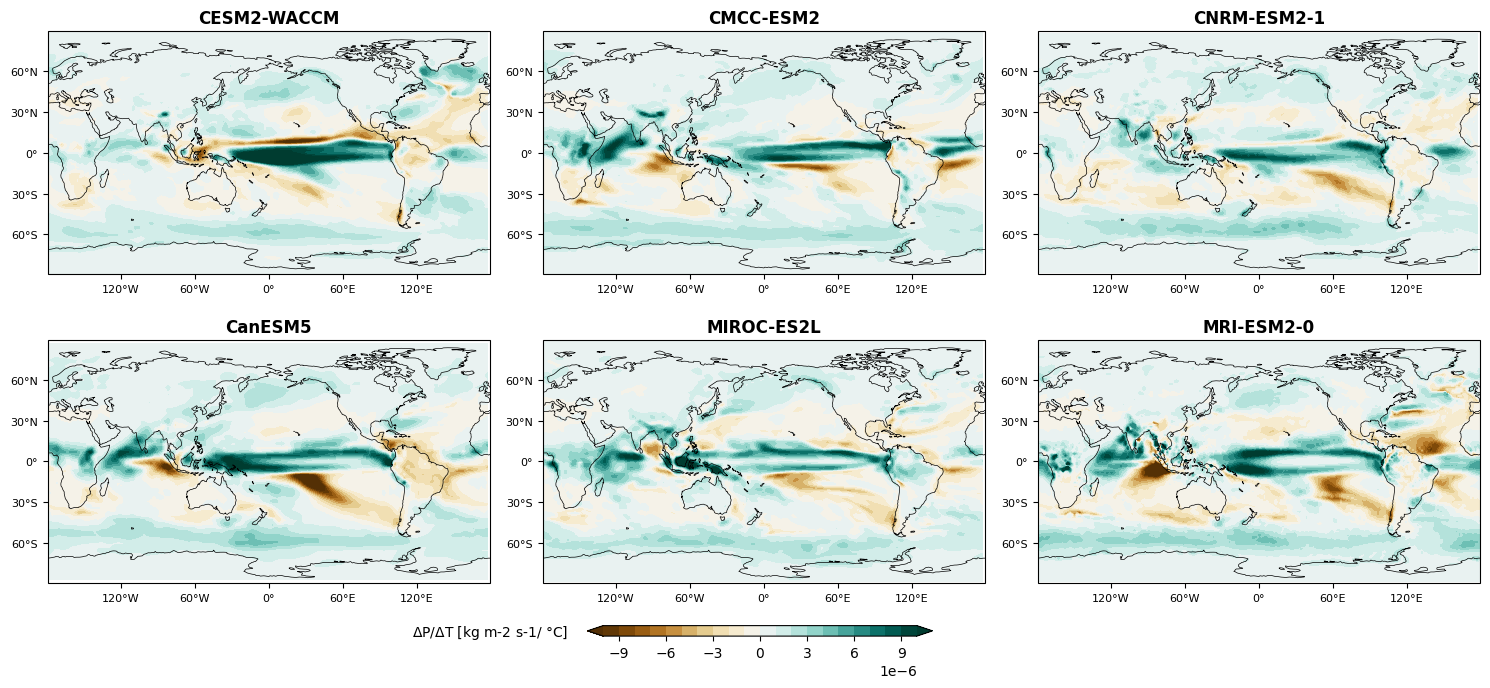

In [48]:
fig = plt.figure(figsize=(15,7), layout="tight")

for nm,mname in enumerate(models_ssp534):
    sub = fig.add_subplot(2,3,nm+1, projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title(mname, weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, patterns_ssp534_common_grid_ts_fit[nm,:,:], cmap="BrBG", levels=np.arange(-1e-5,1e-5,0.1e-5), extend="both", transform=cart.crs.PlateCarree())
    if nm == 0:
        cbar_ax = fig.add_axes([0.395, 0.03, 0.23, 0.015])
        cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        fig.text(0.33,0.03,"$\Delta$P/$\Delta$T [kg m-2 s-1/ °C]",ha="center")
    sub.set_aspect(1.1)

plt.savefig(os.path.join(figdir, "CMIP_SSP534_pr_tas_corr_spatial.pdf"), bbox_inches='tight')

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_84291/786137001.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "recon_SSP534_pr_tas_corr_spatial.pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_84291/786137001.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "recon_SSP534_pr_tas_corr_spatial.pdf"), bbox_inches='tight')
/Users/nste/Documents/entra/projects/d41_METEOR/d41.scripts/METEOR/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


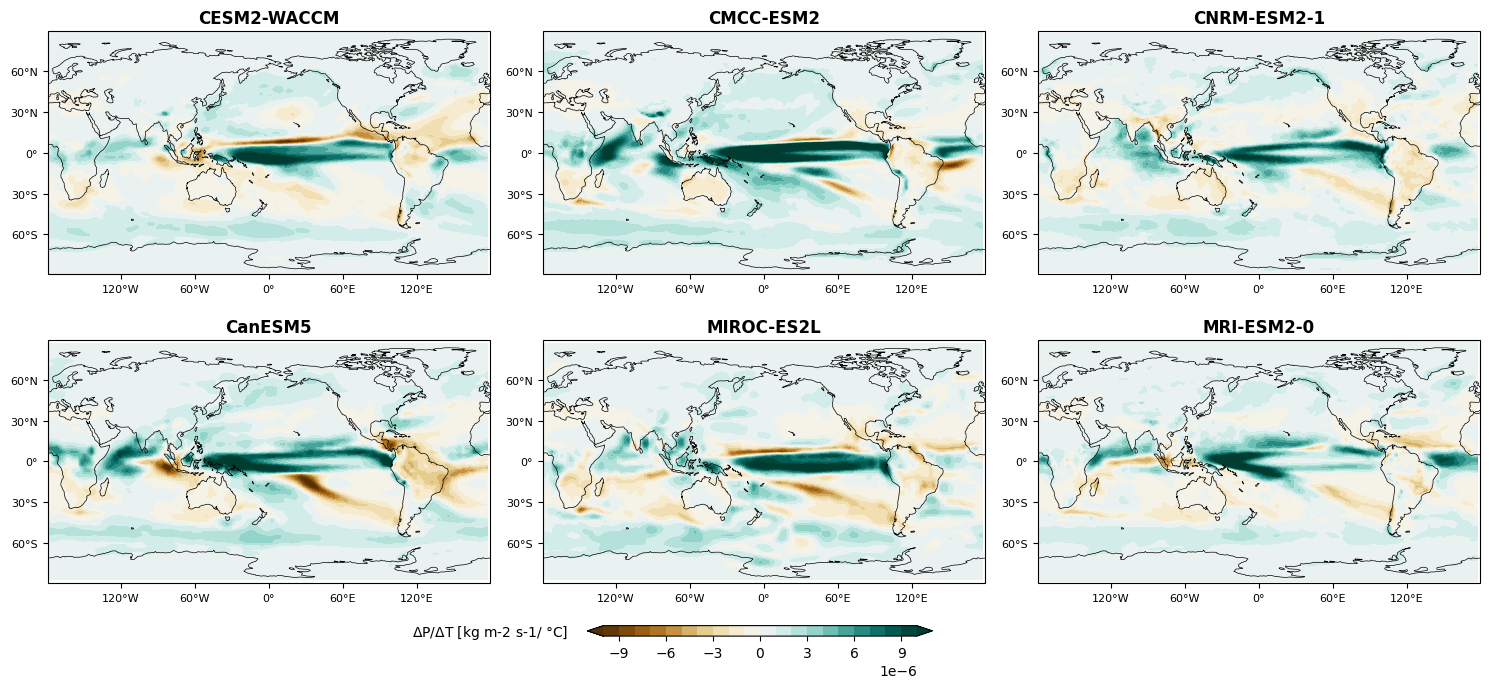

In [49]:
fig = plt.figure(figsize=(15,7), layout="tight")

for nm,mname in enumerate(models_ssp534):
    sub = fig.add_subplot(2,3,nm+1, projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title(mname, weight="bold")
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(target_lons, target_lats, td_ssp534_common_grid_ts_fit[nm,:,:], cmap="BrBG", levels=np.arange(-1e-5,1e-5,0.1e-5), extend="both", transform=cart.crs.PlateCarree())
    if nm == 0:
        cbar_ax = fig.add_axes([0.395, 0.03, 0.23, 0.015])
        cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
        fig.text(0.33,0.03,"$\Delta$P/$\Delta$T [kg m-2 s-1/ °C]",ha="center")
    sub.set_aspect(1.1)

plt.savefig(os.path.join(figdir, "recon_SSP534_pr_tas_corr_spatial.pdf"), bbox_inches='tight')